## Piotr Błaszczyk
## Lab 2

#### funkcje na których będziemy testować

In [24]:
import numpy as np
from abc import ABC, abstractmethod

class Problem(ABC):
    @abstractmethod
    def __call__(self, x: np.ndarray) -> float:
        """Compute the function value at point x."""
        raise NotImplementedError
    
    @abstractmethod
    def grad(self, x: np.ndarray) -> np.ndarray:
        """Compute the gradient at point x."""
        raise NotImplementedError

class Sphere(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(x**2)
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        return 2 * x

class Rosenbrock(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        grad = np.zeros_like(x)
        n = x.size
        grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
        for i in range(1, n - 1):
            grad[i] = 200 * (x[i] - x[i-1]**2) - 400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
        grad[-1] = 200 * (x[-1] - x[-2]**2)
        return grad

class Rastrigin(Problem):
    def __call__(self, x: np.ndarray) -> float:
        A = 10
        n = x.size
        return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        A = 10
        return 2 * x + 2 * np.pi * A * np.sin(2 * np.pi * x)


#### funkcje do wizualizacji

In [25]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def prepare_mesh_grid(
    problem: Problem,
    bounds: tuple[float, float] = (-5.0, 5.0),
    grid_size: int = 50,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_vals = np.linspace(bounds[0], bounds[1], grid_size)
    y_vals = np.linspace(bounds[0], bounds[1], grid_size)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = np.zeros_like(X)
    for i in range(grid_size):
        for j in range(grid_size):
            xy = np.array([X[i, j], Y[i, j]])
            Z[i, j] = problem(xy)

    return X, Y, Z, x_vals, y_vals


def plot_3d_surface(
    problem: Problem,
    grid_size: int = 50,
):
    X, Y, Z, _, _ = prepare_mesh_grid(problem=problem, grid_size=grid_size)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

    ax.set_title(problem.__class__.__name__)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")

    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.tight_layout()
    plt.show()

def plot_contour_and_paths(
    problem: Problem,
    paths: list[np.ndarray],
    grid_size: int = 200,
    title: str = "",
):
    """
    Create an interactive contour plot of a 2D function and overlay multiple optimization paths.

    Args:
        problem: An instance of a Problem class.
        paths: List of numpy arrays; each array is of shape (epochs, 2) containing an optimization trajectory.
        title: Title for the plot.
    """
    _, _, Z, x_vals, y_vals = prepare_mesh_grid(problem, grid_size=grid_size)

    fig = go.Figure(
        data=go.Contour(
            x=x_vals,
            y=y_vals,
            z=Z,
            colorscale="Viridis",
            contours=dict(showlines=False),
            colorbar=dict(title="Function Value"),
        )
    )

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'pink', 'brown']
    
    for idx, path in enumerate(paths):
        color_idx = idx % len(colors)
        fig.add_trace(
            go.Scatter(
                x=path[:, 0],
                y=path[:, 1],
                mode="lines+markers",
                marker=dict(size=4),
                line=dict(width=2, color=colors[color_idx]),
                name=f"Run {idx+1}",
                showlegend=True,
            )
        )

    fig.update_layout(
        title=title, xaxis_title="x", yaxis_title="y", width=800, height=700,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.show()

#### Implementacja momentum

In [26]:
def momentum(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta: float,
    number_of_epochs: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    solution = initial_solution.copy()
    velocity = np.zeros_like(solution)

    dim = solution.shape[0]

    positions = np.zeros((number_of_epochs, dim))
    function_values = np.zeros(number_of_epochs)
    velocity_norms = np.zeros(number_of_epochs)

    for epoch in range(number_of_epochs):
        gradient = problem.grad(solution)
        velocity = beta * velocity + alpha * gradient
        solution = solution - velocity

        positions[epoch] = solution
        function_values[epoch] = problem(solution)
        velocity_norms[epoch] = np.linalg.norm(velocity)

    return positions, function_values, velocity_norms

#### "Eksperymenty"

#### jakby co, będę pisał "szybkość" po "fizycznemu" 🤓 jako sklar z wektora prędkości

#### funkcja do odpalenia pojedyńczego eksperymentu

In [27]:
def run_momentum_experiment_verbose(
    problem: Problem,
    problem_name: str,
    initial_solution: np.ndarray,
    alpha: float,
    beta: float,
    number_of_epochs: int,
):
    print("\n" + "=" * 60)
    print(f"START eksperymentu: {problem_name}")
    print(f"Parametry: alpha={alpha}, beta={beta}, epoki={number_of_epochs}")
    print(f"Punkt startowy: {initial_solution}")
    
    positions, function_values, velocity_norms = momentum(
        problem=problem,
        initial_solution=initial_solution,
        alpha=alpha,
        beta=beta,
        number_of_epochs=number_of_epochs,
    )

    print("\n--- PODSUMOWANIE ---")
    print(f"Wartość funkcji na początku: {function_values[0]:.6f}")
    print(f"Wartość funkcji na końcu:   {function_values[-1]:.6f}")
    print(f"Minimalna wartość funkcji:  {np.min(function_values):.6f}")
    print(f"Maksymalna wartość funkcji: {np.max(function_values):.6f}")

    print(f"\nSzybkość na początku: {velocity_norms[0]:.6f}")
    print(f"Szybkość na końcu:   {velocity_norms[-1]:.6f}")

    if function_values[-1] < function_values[0]:
        print("Funkcja maleje - optymalizacja działa")
    else:
        print("Funkcja nie maleje - coś jest nie tak")

    print("=" * 60)

    # Wykresy
    epochs = np.arange(1, number_of_epochs + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, function_values)
    plt.xlabel("Epoka")
    plt.ylabel("Wartość funkcji")
    plt.title(f"{problem_name} - wartość funkcji vs epoka")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, velocity_norms)
    plt.xlabel("Epoka")
    plt.ylabel("szybkość ( po fizycznemu skalar z wektora )")
    plt.title(f"{problem_name} - szybkość vs epoka")
    plt.grid(True)
    plt.show()

    return positions, function_values, velocity_norms

#### funkcja do porównania learning rate

In [28]:
def compare_learning_rates_verbose(
    problem: Problem,
    problem_name: str,
    initial_solution: np.ndarray,
    alphas: list[float],
    beta: float,
    number_of_epochs: int,
):
    print("\n" + "#" * 60)
    print(f"PORÓWNANIE learning rate dla: {problem_name}")
    print(f"Beta: {beta}, epoki: {number_of_epochs}")
    print("#" * 60)

    epochs = np.arange(1, number_of_epochs + 1)
    all_paths = []

    plt.figure(figsize=(8, 5))

    for alpha in alphas:
        print(f"\n--- alpha = {alpha} ---")

        positions, function_values, velocity_norms = momentum(
            problem=problem,
            initial_solution=initial_solution,
            alpha=alpha,
            beta=beta,
            number_of_epochs=number_of_epochs,
        )

        all_paths.append(positions)

        print(f"Start: {function_values[0]:.6f}")
        print(f"Koniec: {function_values[-1]:.6f}")
        print(f"Min: {np.min(function_values):.6f}")

        if function_values[-1] < function_values[0]:
            print("Spadek wartości funkcji")
        else:
            print("Brak spadku")

        print(f"Szybkość (koniec): {velocity_norms[-1]:.6f}")

        plt.plot(epochs, function_values, label=f"alpha={alpha}")

    plt.xlabel("Epoka")
    plt.ylabel("Wartość funkcji")
    plt.title(f"{problem_name} - porównanie alpha")
    plt.grid(True)
    plt.legend()
    plt.show()

    return all_paths

In [29]:
initial_solution = np.array([2.0, 2.0])
alpha = 0.01
beta = 0.9
number_of_epochs = 100

sphere = Sphere()
rosenbrock = Rosenbrock()
rastrigin = Rastrigin()

#### pojedyńcze eksperymenty


START eksperymentu: Sphere
Parametry: alpha=0.01, beta=0.9, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 7.683200
Wartość funkcji na końcu:   0.000143
Minimalna wartość funkcji:  0.000005
Maksymalna wartość funkcji: 7.683200

Szybkość na początku: 0.056569
Szybkość na końcu:   0.001883
Funkcja maleje - optymalizacja działa


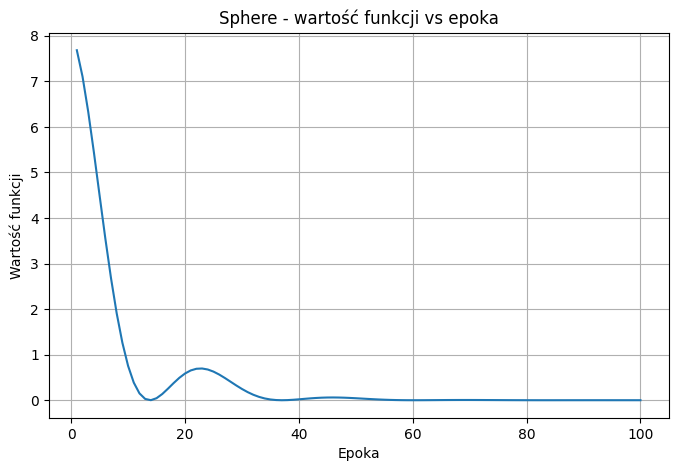

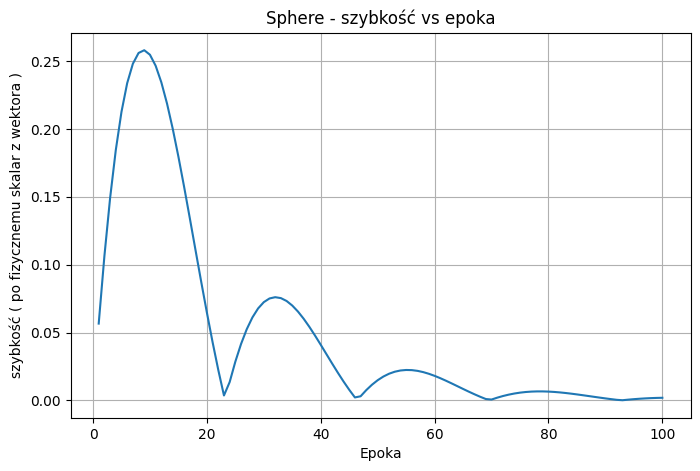

In [30]:
sphere_positions, _, _ = run_momentum_experiment_verbose(
    sphere, "Sphere", initial_solution, alpha, beta, number_of_epochs
)

#### no wygląda spoko, na "intuicje" czuć, że jakby ta przysłowiowa kulka przyspieszka z górki, wjeżdża wyżej, i potem w drugą stronę. No i ładnie widać koleralcję w "konwergacji" 


START eksperymentu: Rosenbrock (alpha=0.01)
Parametry: alpha=0.01, beta=0.9, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 3631552.205216
Wartość funkcji na końcu:   nan
Minimalna wartość funkcji:  nan
Maksymalna wartość funkcji: nan

Szybkość na początku: 16.511826
Szybkość na końcu:   nan
Funkcja nie maleje - coś jest nie tak


C:\Users\piotr\AppData\Local\Temp\ipykernel_15024\430869439.py:24: RuntimeWarning: overflow encountered in square
  return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)
C:\Users\piotr\AppData\Local\Temp\ipykernel_15024\430869439.py:29: RuntimeWarning: overflow encountered in scalar multiply
  grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
C:\Users\piotr\AppData\Local\Temp\ipykernel_15024\762209669.py:19: RuntimeWarning: invalid value encountered in add
  velocity = beta * velocity + alpha * gradient


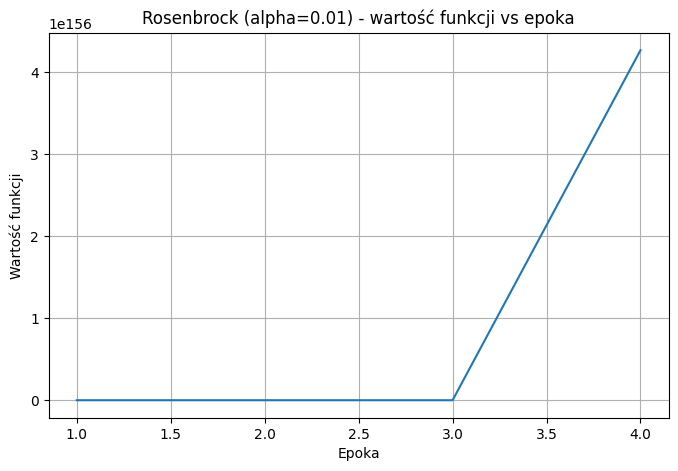

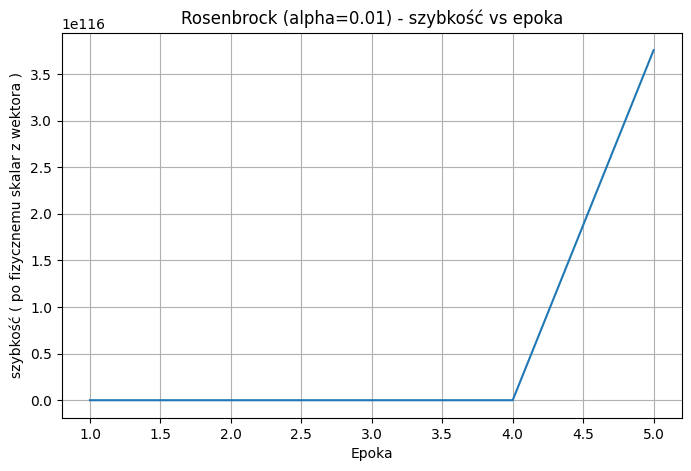


START eksperymentu: Rosenbrock (alpha=0.001)
Parametry: alpha=0.001, beta=0.9, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 502.837667
Wartość funkcji na końcu:   0.252893
Minimalna wartość funkcji:  0.252266
Maksymalna wartość funkcji: 801.801286

Szybkość na początku: 1.651183
Szybkość na końcu:   0.009254
Funkcja maleje - optymalizacja działa


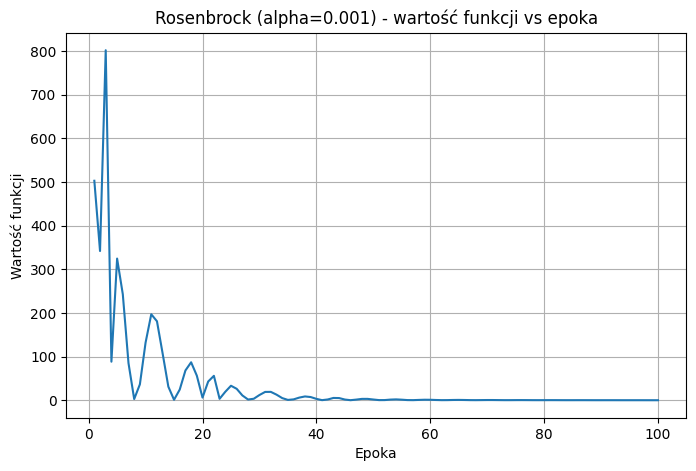

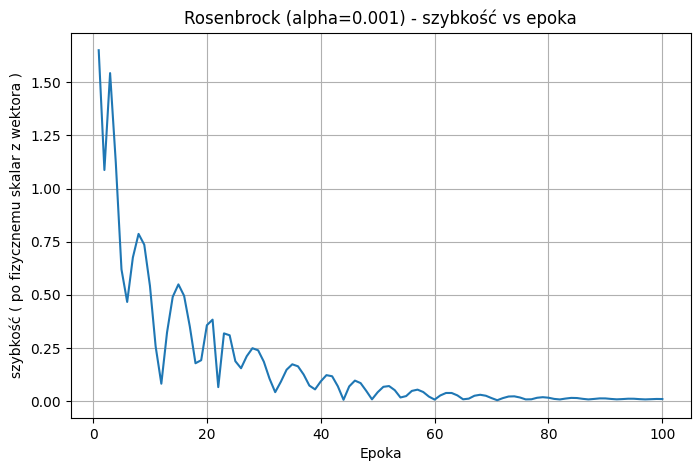


START eksperymentu: Rosenbrock (alpha=0.0001)
Parametry: alpha=0.0001, beta=0.9, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 181.571193
Wartość funkcji na końcu:   0.027893
Minimalna wartość funkcji:  0.019435
Maksymalna wartość funkcji: 196.396735

Szybkość na początku: 0.165118
Szybkość na końcu:   0.000434
Funkcja maleje - optymalizacja działa


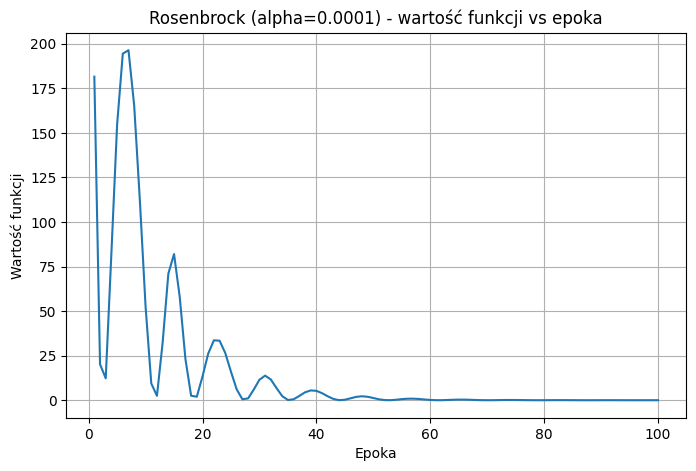

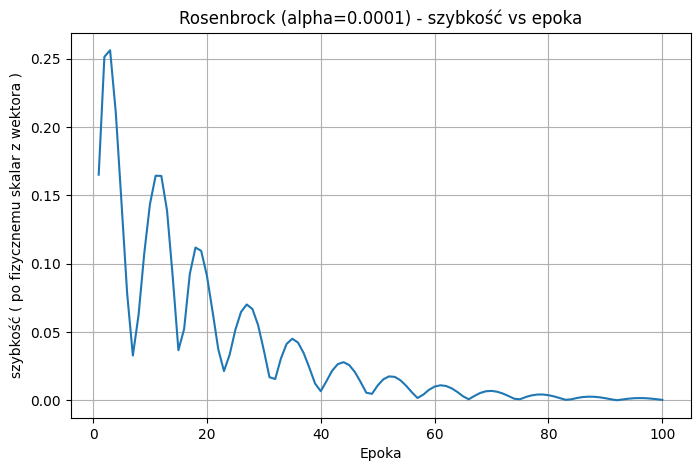

In [31]:
initial_solution = np.array([2.0, 2.0])
beta = 0.9
number_of_epochs = 100

rosenbrock = Rosenbrock()

# ===== alpha = 0.01 =====
alpha = 0.01
rosen_positions_01, _, _ = run_momentum_experiment_verbose(
    rosenbrock, "Rosenbrock (alpha=0.01)", initial_solution, alpha, beta, number_of_epochs
)

# ===== alpha = 0.001 =====
alpha = 0.001
rosen_positions_001, _, _ = run_momentum_experiment_verbose(
    rosenbrock, "Rosenbrock (alpha=0.001)", initial_solution, alpha, beta, number_of_epochs
)

# ===== alpha = 0.0001 =====
alpha = 0.0001
rosen_positions_0001, _, _ = run_momentum_experiment_verbose(
    rosenbrock, "Rosenbrock (alpha=0.0001)", initial_solution, alpha, beta, number_of_epochs
)

#### dla alpha 0.001 i 0.0001 jest ładnie i fajnie, natomiast dla alpha = 0.01 wybuchło. Za duże learning rate, pewnie wjehcaliśmy w jakąś "rampe" i nas wywaliło nie wiadomo gdzie


START eksperymentu: Rastrigin (alpha=0.01)
Parametry: alpha=0.01, beta=0.9, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 8.311537
Wartość funkcji na końcu:   10.283414
Minimalna wartość funkcji:  8.311537
Maksymalna wartość funkcji: 12.771376

Szybkość na początku: 0.056569
Szybkość na końcu:   0.221348
Funkcja nie maleje - coś jest nie tak


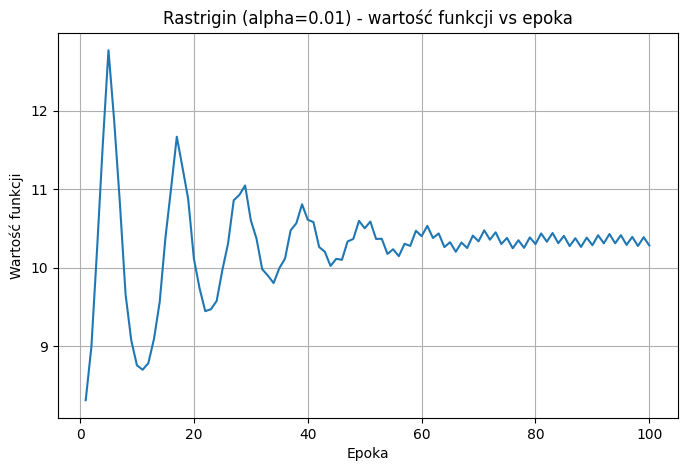

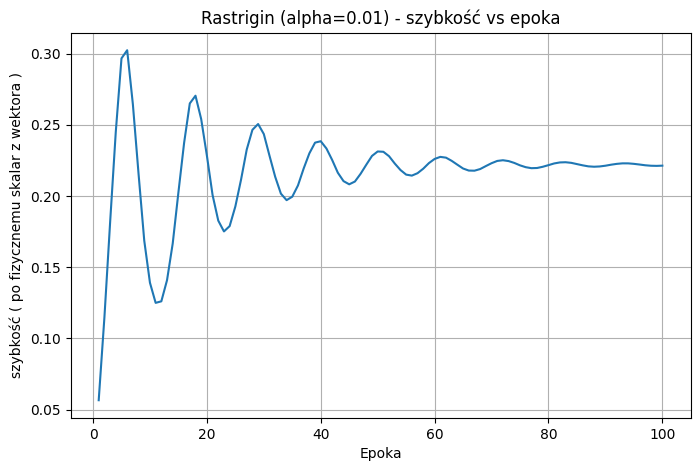


START eksperymentu: Rastrigin (alpha=0.001)
Parametry: alpha=0.001, beta=0.9, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 7.974348
Wartość funkcji na końcu:   7.959663
Minimalna wartość funkcji:  7.959662
Maksymalna wartość funkcji: 7.985875

Szybkość na początku: 0.005657
Szybkość na końcu:   0.000020
Funkcja maleje - optymalizacja działa


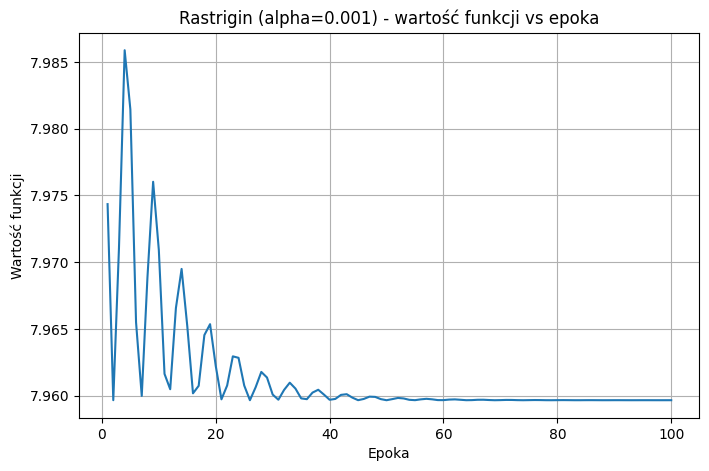

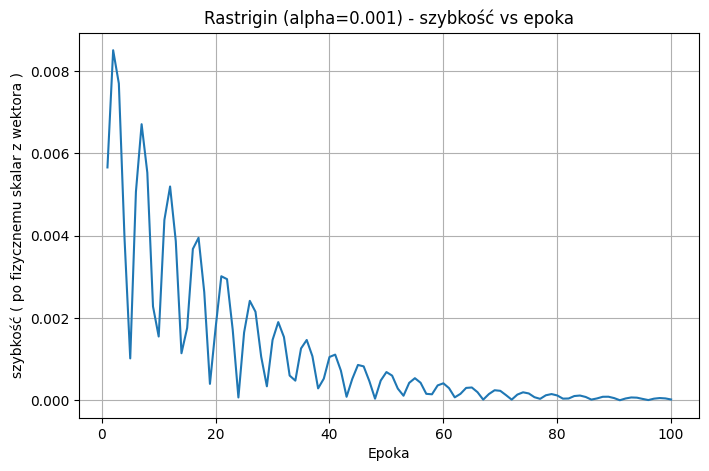


START eksperymentu: Rastrigin (alpha=0.0001)
Parametry: alpha=0.0001, beta=0.9, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 7.996863
Wartość funkcji na końcu:   7.959663
Minimalna wartość funkcji:  7.959662
Maksymalna wartość funkcji: 7.996863

Szybkość na początku: 0.000566
Szybkość na końcu:   0.000012
Funkcja maleje - optymalizacja działa


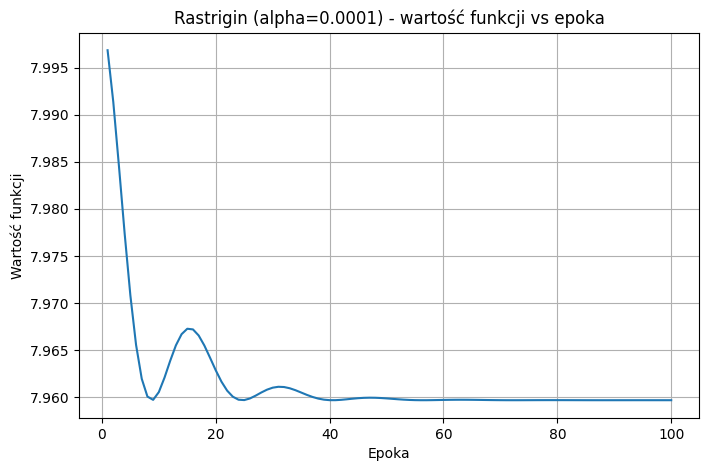

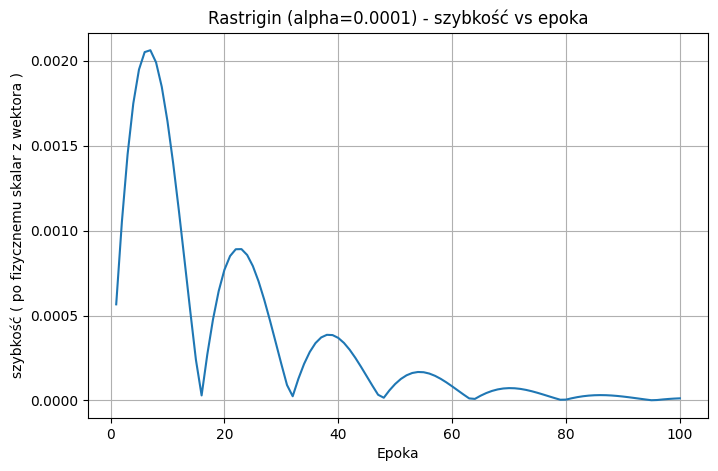

In [32]:
initial_solution = np.array([2.0, 2.0])
beta = 0.9
number_of_epochs = 100

rastrigin = Rastrigin()

# ===== alpha = 0.01 =====
alpha = 0.01
rastrigin_positions_01, _, _ = run_momentum_experiment_verbose(
    rastrigin, "Rastrigin (alpha=0.01)", initial_solution, alpha, beta, number_of_epochs
)

# ===== alpha = 0.001 =====
alpha = 0.001
rastrigin_positions_001, _, _ = run_momentum_experiment_verbose(
    rastrigin, "Rastrigin (alpha=0.001)", initial_solution, alpha, beta, number_of_epochs
)

# ===== alpha = 0.0001 =====
alpha = 0.0001
rastrigin_positions_0001, _, _ = run_momentum_experiment_verbose(
    rastrigin, "Rastrigin (alpha=0.0001)", initial_solution, alpha, beta, number_of_epochs
)

#### no działa fajnie. Jedyna różnica, że dla różnych wartości alfa dzieje sie praktycznie to samo, tylko że dla mniejszych jest bardziej "smooth"

### 4. Momentum Hyperparameters

Fix `alpha = 1e-4, initial_solution = np.array([2.0, 2.0]), number_of_epochs = 100`.
Use $\beta \in [0.5, 0.75, 0.9, 0.95, 0.99]$ on the Rosenbrock function. How does increasing $\beta$ affect convergence? Stability?


START eksperymentu: Rosenbrock (beta=0.5)
Parametry: alpha=0.0001, beta=0.5, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 181.571193
Wartość funkcji na końcu:   0.210912
Minimalna wartość funkcji:  0.210912
Maksymalna wartość funkcji: 181.571193

Szybkość na początku: 0.165118
Szybkość na końcu:   0.000060
Funkcja maleje - optymalizacja działa


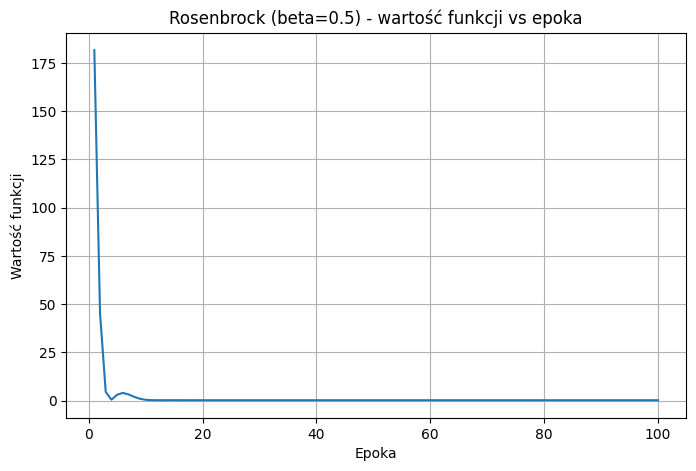

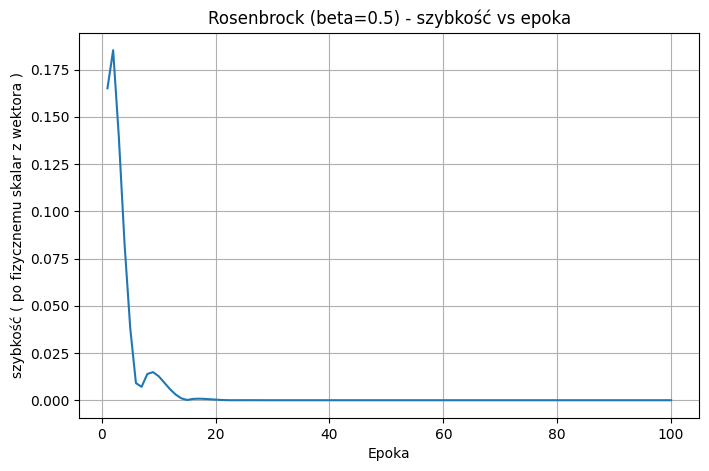


START eksperymentu: Rosenbrock (beta=0.75)
Parametry: alpha=0.0001, beta=0.75, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 181.571193
Wartość funkcji na końcu:   0.182936
Minimalna wartość funkcji:  0.182936
Maksymalna wartość funkcji: 181.571193

Szybkość na początku: 0.165118
Szybkość na końcu:   0.000113
Funkcja maleje - optymalizacja działa


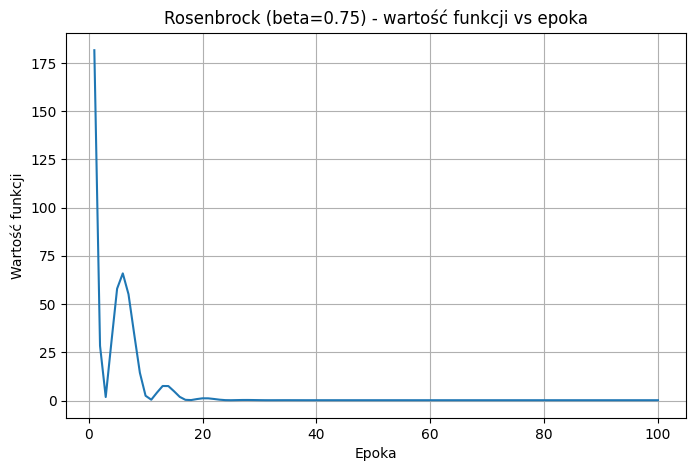

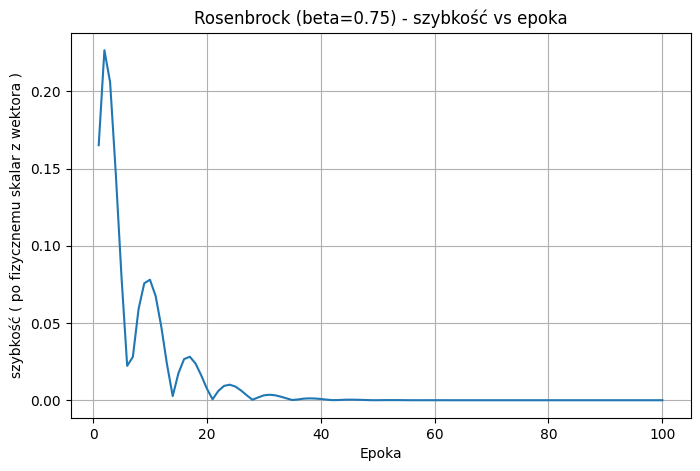


START eksperymentu: Rosenbrock (beta=0.9)
Parametry: alpha=0.0001, beta=0.9, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 181.571193
Wartość funkcji na końcu:   0.027893
Minimalna wartość funkcji:  0.019435
Maksymalna wartość funkcji: 196.396735

Szybkość na początku: 0.165118
Szybkość na końcu:   0.000434
Funkcja maleje - optymalizacja działa


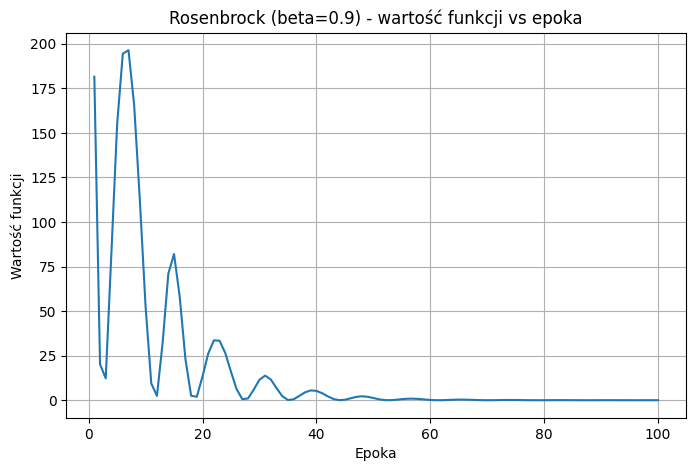

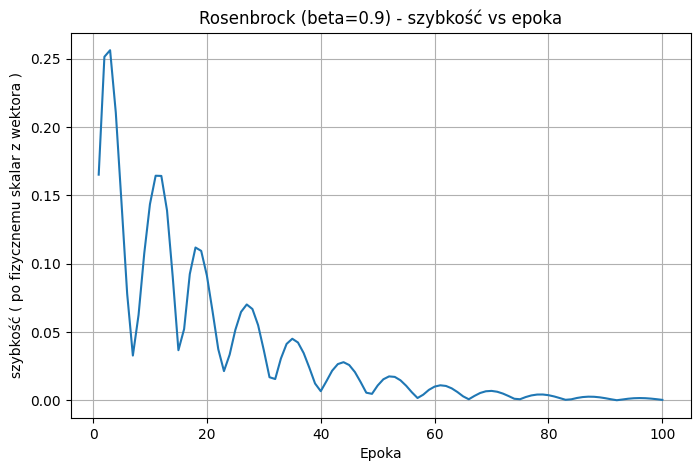


START eksperymentu: Rosenbrock (beta=0.95)
Parametry: alpha=0.0001, beta=0.95, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 181.571193
Wartość funkcji na końcu:   2.855911
Minimalna wartość funkcji:  0.397042
Maksymalna wartość funkcji: 280.382112

Szybkość na początku: 0.165118
Szybkość na końcu:   0.008319
Funkcja maleje - optymalizacja działa


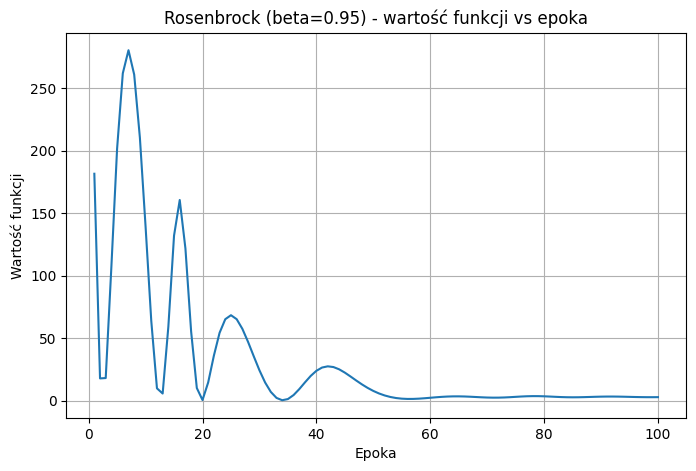

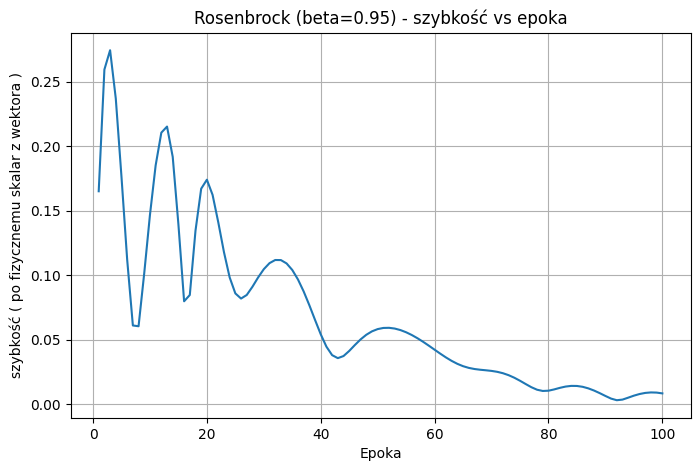


START eksperymentu: Rosenbrock (beta=0.99)
Parametry: alpha=0.0001, beta=0.99, epoki=100
Punkt startowy: [2. 2.]

--- PODSUMOWANIE ---
Wartość funkcji na początku: 181.571193
Wartość funkcji na końcu:   41.711697
Minimalna wartość funkcji:  0.138855
Maksymalna wartość funkcji: 359.752015

Szybkość na początku: 0.165118
Szybkość na końcu:   0.130906
Funkcja maleje - optymalizacja działa


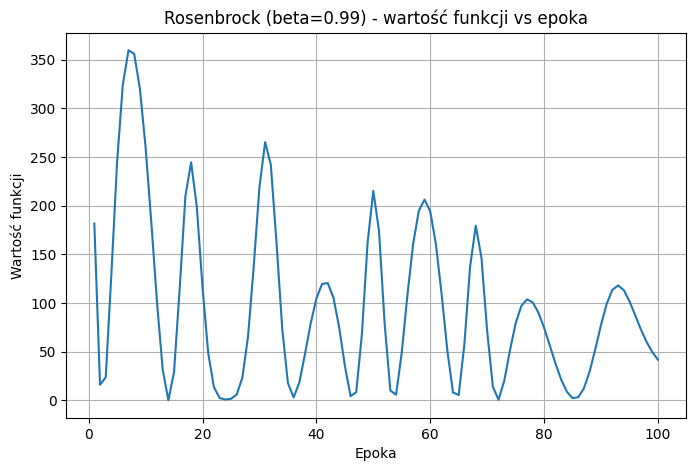

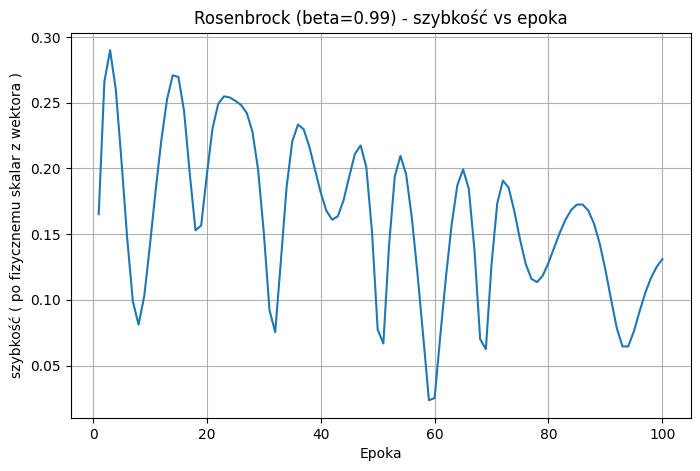

In [33]:
initial_solution = np.array([2.0, 2.0])
alpha = 1e-4
number_of_epochs = 100

rosenbrock = Rosenbrock()

betas = [0.5, 0.75, 0.9, 0.95, 0.99]

for beta in betas:
    rosen_positions, _, _ = run_momentum_experiment_verbose(
        rosenbrock,
        f"Rosenbrock (beta={beta})",
        initial_solution,
        alpha,
        beta,
        number_of_epochs
    )

#### no beta = 0.5 bije na łopatki wszystkie inne. Praktycznie od razu "wskoczyliśmy" w dobre miejsce. A beta=0.99 to totala porażka. W przypadku tej funkcji i tego kokretnego punktu startowego prosty wniosek: mniejsze beta lepsze. Penwnie dlatego, że na poczatku zbyt mocno się "rozpędza" i już nie idzie tego zatrzymać

#### Implementacja Adama

In [34]:
def adam(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta1: float,
    beta2: float,
    number_of_epochs: int,
    epsilon: float = 1e-8
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    solution = initial_solution.copy()
    dim = solution.shape[0]

    m = np.zeros_like(solution)  
    v = np.zeros_like(solution) 

    positions = np.zeros((number_of_epochs, dim))
    function_values = np.zeros(number_of_epochs)
    gradient_norms = np.zeros(number_of_epochs)

    for epoch in range(number_of_epochs):
        t = epoch + 1

        gradient = problem.grad(solution)

        m = beta1 * m + (1 - beta1) * gradient
        v = beta2 * v + (1 - beta2) * (gradient ** 2)

        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        solution = solution - alpha * m_hat / (np.sqrt(v_hat) + epsilon)

        positions[epoch] = solution
        function_values[epoch] = problem(solution)
        gradient_norms[epoch] = np.linalg.norm(gradient)

    return positions, function_values, gradient_norms

#### eksperyment

In [35]:
# Momentum
sphere_pos_mom, sphere_val_mom, _ = momentum(
    sphere, initial_solution, 0.01, 0.9, number_of_epochs
)

# Adam
sphere_pos_adam, sphere_val_adam, _ = adam(
    sphere, initial_solution, 0.01, 0.9, 0.999, number_of_epochs
)

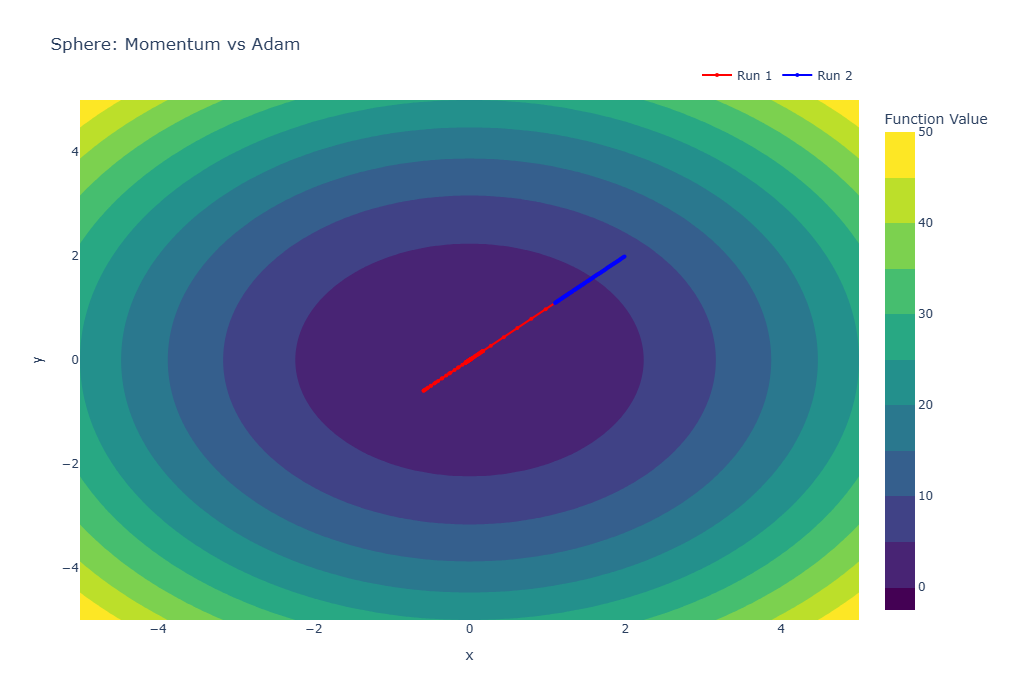

In [36]:
plot_contour_and_paths(
    problem=sphere,
    paths=[sphere_pos_mom, sphere_pos_adam],
    title="Sphere: Momentum vs Adam"
)

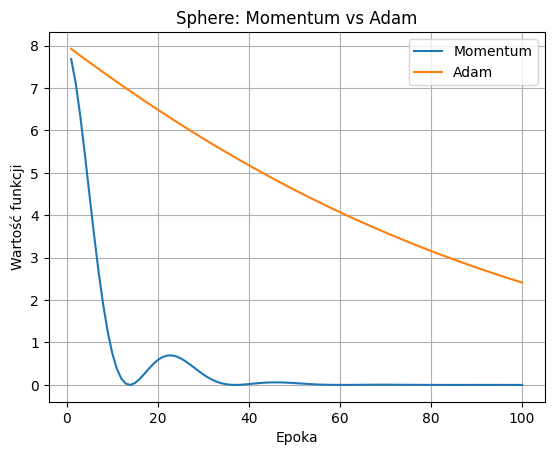

In [37]:
epochs = np.arange(1, number_of_epochs + 1)

plt.figure()
plt.plot(epochs, sphere_val_mom, label="Momentum")
plt.plot(epochs, sphere_val_adam, label="Adam")
plt.xlabel("Epoka")
plt.ylabel("Wartość funkcji")
plt.title("Sphere: Momentum vs Adam")
plt.legend()
plt.grid(True)
plt.show()

#### No niby Adam miał być taki super i w ogóle, a tutaj wypadł mega słabo w porównaniu z momentum. 
#### Pewnie dlatego, że Adam za szybko hamuje, bo "oho duży gradient lepij spowolnijmy" no i tak to się kończy. Więc dla prostej funkcji jak sphere gradient wygrał.

#### wniosek: nie zakładać ślepo że Adam >>>> reszta 

#### Dam adamowi 2gą szanse

In [42]:
number_of_epochs = 1_000

# Momentum
sphere_pos_mom, sphere_val_mom, _ = momentum(
    sphere, initial_solution, 0.01, 0.9, number_of_epochs
)

# Adam
sphere_pos_adam, sphere_val_adam, _ = adam(
    sphere, initial_solution, 0.01, 0.9, 0.999, number_of_epochs
)

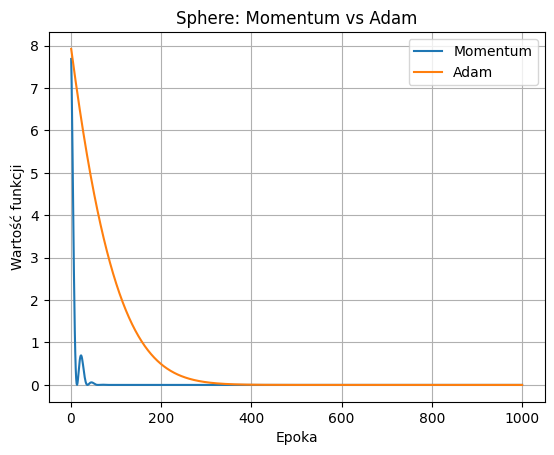

In [43]:
epochs = np.arange(1, number_of_epochs + 1)

plt.figure()
plt.plot(epochs, sphere_val_mom, label="Momentum")
plt.plot(epochs, sphere_val_adam, label="Adam")
plt.xlabel("Epoka")
plt.ylabel("Wartość funkcji")
plt.title("Sphere: Momentum vs Adam")
plt.legend()
plt.grid(True)
plt.show()

#### No jak widać, Adam działa, ale tutaj jest po prostu powolny. Czyli jak zwykle: "right tool for the right job"